In [1]:
import os
import math
from define_models import baselines
import matplotlib.pyplot as plt
from IPython.display import display
# from critdd import Diagram, Diagrams
from collections import defaultdict
from numbers import Number
import texfig as tf
from texfig import TMLR_textwidth
import os
import pandas as pd
import numpy as np
import h5py
from benchmark_analysis import load_estim

no GPU found


In [2]:
output_dir = "Projects/mislabeled-benchmark/ecai-output-sigmoid"

In [3]:
result_dirs = [
    (
        "weak/klm",
        os.path.join(os.path.expanduser("~"), f"{output_dir}/weak/klm"),
    ),
    # (
    #     "noise/klm",
    #     os.path.join(os.path.expanduser("~"), f"{output_dir}/noise/klm"),
    # ),
]


In [4]:
def custom_grid(axis):
    axis.grid(c="#f2f2f2", which="both")
    axis.set_axisbelow(True)

In [5]:
all_results = dict()

In [6]:
all_results["allclass"] = dict()
for prefix, result_dir in result_dirs:
    all_results["allclass"][prefix] = load_estim(result_dir=result_dir)

In [7]:
detectors = np.unique(
    np.concatenate([r.detector_name.unique() for r in all_results['allclass'].values()])
)
datasets = np.unique(np.concatenate([r.dataset_name.unique() for r in all_results['allclass'].values()]))

detectors_nobaseline = list(set(detectors) - set(baselines + ["random"]))

len(detectors), detectors, len(detectors_nobaseline), detectors_nobaseline, len(
    datasets
), datasets

(46,
 array(['gold', 'isotonic', 'klm_aum', 'klm_aum_adjusted',
        'klm_aum_isotonic_0.05', 'klm_aum_isotonic_0.1',
        'klm_aum_isotonic_0.2', 'klm_aum_isotonic_0.3',
        'klm_aum_isotonic_0.4', 'klm_aum_isotonic_0.5',
        'klm_aum_isotonic_noisy_0.2', 'klm_aum_sigmoid_0.2',
        'klm_cleanlab', 'klm_cleanlab_adjusted',
        'klm_cleanlab_isotonic_0.05', 'klm_cleanlab_isotonic_0.1',
        'klm_cleanlab_isotonic_0.2', 'klm_cleanlab_isotonic_0.3',
        'klm_cleanlab_isotonic_0.4', 'klm_cleanlab_isotonic_0.5',
        'klm_cleanlab_isotonic_noisy_0.2', 'klm_cleanlab_sigmoid_0.2',
        'klm_consensus', 'klm_consensus_adjusted',
        'klm_consensus_isotonic_0.05', 'klm_consensus_isotonic_0.1',
        'klm_consensus_isotonic_0.2', 'klm_consensus_isotonic_0.3',
        'klm_consensus_isotonic_0.4', 'klm_consensus_isotonic_0.5',
        'klm_consensus_isotonic_noisy_0.2', 'klm_consensus_sigmoid_0.2',
        'klm_smallloss', 'klm_smallloss_adjusted',
       

In [8]:
d_base_model_map = dict()
d_detect_map = dict()

for d in detectors_nobaseline:
    s = d.split("_")
    if len(s) >= 2:
        d_base_model_map[d] = s[0]
    else:
        d_base_model_map[d] = "klm"

    d_detect_map[d] = " ".join(s[1:3])

detector_suffixes = np.unique(list(d_detect_map.values()))
detector_base = np.unique([v.split(" ")[0] for v in detector_suffixes])
d_base_model_map, d_detect_map, detector_suffixes, detector_base

({'klm_consensus_isotonic_0.2': 'klm',
  'klm_smallloss_isotonic_noisy_0.2': 'klm',
  'klm_smallloss_adjusted': 'klm',
  'klm_aum_isotonic_0.1': 'klm',
  'klm_cleanlab_isotonic_0.3': 'klm',
  'klm_consensus_isotonic_noisy_0.2': 'klm',
  'klm_cleanlab_isotonic_0.5': 'klm',
  'klm_cleanlab_isotonic_0.05': 'klm',
  'klm_smallloss_isotonic_0.05': 'klm',
  'klm_consensus_isotonic_0.05': 'klm',
  'klm_aum': 'klm',
  'klm_aum_isotonic_0.2': 'klm',
  'klm_aum_isotonic_noisy_0.2': 'klm',
  'klm_consensus': 'klm',
  'klm_smallloss_sigmoid_0.2': 'klm',
  'klm_cleanlab_isotonic_0.2': 'klm',
  'klm_consensus_sigmoid_0.2': 'klm',
  'klm_aum_isotonic_0.5': 'klm',
  'klm_cleanlab_isotonic_0.1': 'klm',
  'klm_cleanlab_sigmoid_0.2': 'klm',
  'klm_consensus_isotonic_0.1': 'klm',
  'klm_consensus_isotonic_0.5': 'klm',
  'klm_aum_isotonic_0.05': 'klm',
  'klm_cleanlab_adjusted': 'klm',
  'klm_smallloss_isotonic_0.3': 'klm',
  'klm_cleanlab': 'klm',
  'klm_smallloss': 'klm',
  'klm_cleanlab_isotonic_noisy_0

In [9]:
detect_pretty_name = {
    "agra": "AGRA",
    "aum": "AUM",
    "calibrated": "(calibrated)",
    "isotonic": "(calibrated isotonic)",
    "sigmoid": "(calibrated sigmoid)",
    "noisy": "(calibrated noisy)",
    "baseline": "(baseline)",
    "adjusted": "(adjusted)",
    "cleanlab": "Cleanlab",
    "consensus": "Consensus",
    "forget": "Forget scores",
    "influence": "Influence",
    "representer": "Representer",
    "smallloss": "Small loss",
    "tracin": "TracIn",
    "vosg": "VoSG",
}

detect_pretty_name = {
    "agra": "AGRA",
    "aum": "AUM",
    "isotonic": "calibrated (isotonic)",
    "sigmoid": "calibrated (sigmoid)",
    "noisy": "(calibrated noisy)",
    "baseline": "baseline",
    "adjusted": "adjusted",
    "cleanlab": "Cleanlab",
    "consensus": "Consensus",
    "forget": "Forget scores",
    "influence": "Influence",
    "representer": "Representer",
    "smallloss": "Small Loss",
    "tracin": "TracIn",
    "vosg": "VoSG",
}

bm_pretty_name = {"klm": "KLM", "gb": "GBT"}

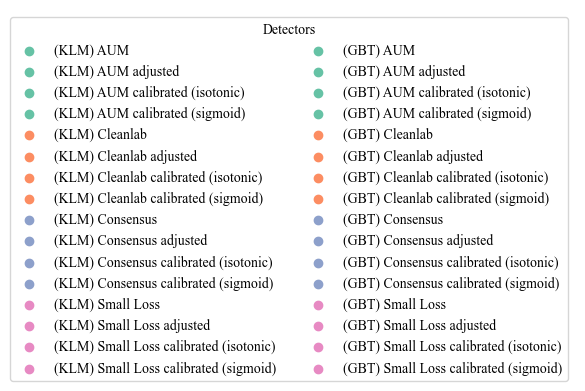

In [10]:
from matplotlib import colormaps
import seaborn as sns

# tab_colors = colormaps["tab20"]
# tab_colors = colormaps["tab10"]
tab_colors = sns.color_palette("Set2", len(detector_base))


def detector_color(detector_name):
    base = detector_name.split(" ")[0]
    mapping = {d: tab_colors[i] for i, d in enumerate(detector_base)}
    return mapping[base]


# detector_colors = {
#     d: tab_colors.colors[i % len(tab_colors.colors)]
#     for i, d in enumerate(detector_suffixes)
# }

plt.figure()
labels = []
# KLM
for d_name in detector_suffixes:
    l = f"({bm_pretty_name['klm']}) " + " ".join(
        [detect_pretty_name[d] for d in d_name.split(" ")[:2]]
    )
    plt.scatter([], [], label=l, color=detector_color(d_name))
    labels.append(l)

# GB
# for d_name, d_color in detector_colors.items():
#     if (
#         len(list(filter(lambda d: ("gb" in d) and (d_name in d), detectors_nobaseline)))
#         >= 1
#     ):
#         l = f"({bm_pretty_name['gb']}) " + " ".join(
#             [detect_pretty_name[d] for d in d_name.split(" ")]
#         )
#         plt.scatter([], [], label=l, color=d_color, marker="s")
#         labels.append(l)
#     else:
#         plt.scatter([], [], label="", color="white", alpha=0)
#         labels.append("")
for d_name in detector_suffixes:
    l = f"({bm_pretty_name['gb']}) " + " ".join(
        [detect_pretty_name[d] for d in d_name.split(" ")[:2]]
    )
    plt.scatter([], [], label=l, color=detector_color(d_name))
    labels.append(l)


disp_baselines = False
if disp_baselines:
    plt.scatter([], [], label="gold", color="black", marker="x")
    labels.append("gold")
    plt.scatter([], [], label="silver", color="black", marker="+")
    labels.append("silver")
    plt.scatter([], [], label="random", color="black", marker="p")
    labels.append("random")

    for i in range(len(detector_colors.items()) - 3):
        plt.scatter([], [], label="", color="white", alpha=0)
        labels.append("")

plt.gca().axis("off")
plt.legend(ncols=3 if disp_baselines else 2, labels=labels, title="Detectors")
# plt.savefig(f"figures/summary/{prefix_txt}_legend.pdf")

In [11]:
full_detector_colors = dict()
full_detector_markers = dict()
for d in detectors:
    if d in baselines + ['random']:
        full_detector_colors[d] = 'white'
        full_detector_markers[d] = 'x'
    else:
        full_detector_colors[d] = detector_color(d_detect_map[d])
        full_detector_markers[d] = 'o' if d_base_model_map[d] == 'klm' else 's'


In [12]:
for k, r in all_results['allclass'].items():
    d = r.pivot_table(
        index="detector_name",
        columns="dataset_name",
        values="estim_time",
        aggfunc="count",
    )
    print(k, d.sum().sum(), d.sum())
    display(d)

weak/klm 283860 dataset_name
agnews               14940
amazon               14940
bank-marketing       14940
basketball           14940
bioresponse          14940
census               14940
commercial           14940
hausa                14940
imdb                 14940
mushroom             14940
phishing             14940
professor_teacher    14940
sms                  14940
spambase             14940
tennis               14940
trec                 14940
yelp                 14940
yoruba               14940
youtube              14940
dtype: int64


dataset_name,agnews,amazon,bank-marketing,basketball,bioresponse,census,commercial,hausa,imdb,mushroom,phishing,professor_teacher,sms,spambase,tennis,trec,yelp,yoruba,youtube
detector_name,,,,,,,,,,,,,,,,,,,
gold,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
isotonic,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36,36
klm_aum,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_adjusted,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_isotonic_0.05,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_isotonic_0.1,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_isotonic_0.2,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_isotonic_0.3,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360
klm_aum_isotonic_0.4,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360,360


In [13]:
for k, r in all_results['allclass'].items():
    print(k)
    display(
        r.pivot_table(
            index="detector_name",
            columns="dataset_name",
            values="logl_test",
            aggfunc="min",
        )
    )

weak/klm


dataset_name,agnews,amazon,bank-marketing,basketball,bioresponse,census,commercial,hausa,imdb,mushroom,phishing,professor_teacher,sms,spambase,tennis,trec,yelp,yoruba,youtube
detector_name,,,,,,,,,,,,,,,,,,,
gold,0.375998,0.181505,0.222091,0.149927,0.549923,0.348389,0.240352,0.636371,0.331368,0.008132,0.144986,0.240484,0.044375,0.197125,0.335230,0.798195,0.194286,0.982271,0.211438
isotonic,0.548341,0.380930,0.294740,0.310690,0.655308,0.475384,0.265050,2.962692,0.505998,0.354779,0.548259,0.402547,0.165924,0.606735,0.484815,2.709365,0.335107,5.182578,0.891972
klm_aum,0.536583,0.591194,0.274208,0.264712,0.940348,0.490060,0.255134,1.483018,0.471750,0.282742,0.345291,0.316502,0.130793,0.537303,0.350178,1.663119,0.543705,1.476487,0.240961
klm_aum_adjusted,0.546665,0.587937,0.314697,0.276437,0.889843,0.517182,0.266470,1.479535,0.481390,0.273415,0.366087,0.318091,0.153249,0.510436,0.342402,1.658668,0.545655,1.489816,0.238925
klm_aum_isotonic_0.05,0.506090,0.349636,0.274954,0.258321,0.673098,0.457484,0.260780,1.315002,0.443036,0.282547,0.382220,0.317414,0.136689,0.330173,0.341676,1.564776,0.354829,1.384871,0.234383
klm_aum_isotonic_0.1,0.509570,0.360100,0.280097,0.252066,0.658648,0.478754,0.257480,1.291465,0.436441,0.281269,0.364872,0.312952,0.132553,0.341905,0.348093,1.625537,0.311048,1.264855,0.225618
klm_aum_isotonic_0.2,0.510532,0.346741,0.277079,0.261165,0.665923,0.459512,0.265676,1.256672,0.435187,0.275323,0.367998,0.312541,0.129243,0.322235,0.342634,1.654374,0.324548,1.289502,0.231675
klm_aum_isotonic_0.3,0.502282,0.359393,0.280524,0.257553,0.691593,0.499511,0.264123,1.288402,0.439979,0.284699,0.357340,0.319571,0.131503,0.330410,0.344301,1.649708,0.329024,1.257339,0.240180
klm_aum_isotonic_0.4,0.526526,0.350432,0.281674,0.259451,0.648926,0.479889,0.264606,1.219243,0.448239,0.284161,0.367386,0.317872,0.129350,0.337085,0.342314,1.656679,0.331268,1.278760,0.247308


In [14]:
# Hyperparameters selection

all_results_cv = dict()
all_val_cv = dict()

baselines_norandom = set(baselines) - {"random"}
for which, _all_res in [("allclass", all_results["allclass"])]:
    all_results_cv[which] = dict()
    all_val_cv[which] = dict()

    for prefix in _all_res.keys():
        all_results_cv[which][prefix] = dict()
        all_val_cv[which][prefix] = dict()

        for cv_k, cv_function in [
            ("logl", lambda d, k: d[f"logl_{k}"].idxmin()),
            ("bacc", lambda d, k: d[f"bacc_{k}"].idxmax()),
            ("ece", lambda d, k: d[f"ece_{k}"].idxmin()),
        ]:
            indices_oracl_cv = cv_function(
                _all_res[prefix].groupby(["dataset_name", "detector_name"]), "test"
            )
            indices_clean_cv = cv_function(
                _all_res[prefix].groupby(["dataset_name", "detector_name"]), "val"
            )
            indices_noisy_cv = cv_function(
                _all_res[prefix].groupby(["dataset_name", "detector_name"]), "noisy_val"
            )
            indices_noisy_10_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.1
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "noisy_val",
            )
            indices_noisy_90_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.9
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "noisy_val",
            )
            indices_clean_90_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.9
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "val",
            )
            indices_clean_10_cv = cv_function(
                _all_res[prefix][
                    _all_res[prefix]["params_splitter"].apply(
                        lambda r: "quantile" in r.keys() and r["quantile"] == 0.1
                    )
                    | _all_res[prefix]["detector_name"].isin(baselines_norandom)
                ].groupby(["dataset_name", "detector_name"]),
                "val",
            )

            all_results_cv[which][prefix][cv_k] = {
                "oracl": _all_res[prefix].loc[indices_oracl_cv.dropna()],
                "clean": _all_res[prefix].loc[indices_clean_cv.dropna()],
                "noisy": _all_res[prefix].loc[indices_noisy_cv.dropna()],
                "noisy_10": _all_res[prefix].loc[indices_noisy_10_cv.dropna()],
                "noisy_90": _all_res[prefix].loc[indices_noisy_90_cv.dropna()],
                "clean_90": _all_res[prefix].loc[indices_clean_90_cv.dropna()],
                "clean_10": _all_res[prefix].loc[indices_clean_10_cv.dropna()],
            }

            all_val_cv[which][prefix][cv_k] = {
                k: r.pivot(
                    index="detector_name", columns="dataset_name", values=f"{cv_k}_test"
                )
                for k, r in all_results_cv[which][prefix][cv_k].items()
            }

        # sanity check
        best_logl_direct = _all_res[prefix].pivot_table(
            index="detector_name",
            columns="dataset_name",
            values="logl_test",
            aggfunc="min",
        )

        assert (
            best_logl_direct - all_val_cv[which][prefix]["logl"]["oracl"]
        ).abs().sum().sum() == 0

        best_bacc_direct = _all_res[prefix].pivot_table(
            index="detector_name",
            columns="dataset_name",
            values="bacc_test",
            aggfunc="max",
        )

        assert (
            best_bacc_direct - all_val_cv[which][prefix]["bacc"]["oracl"]
        ).abs().sum().sum() == 0

hp_tune_str = {
    "oracl": "oracle",
    "clean": "clean validation set",
    "noisy": "noisy validation set",
    "noisy_10": "noisy validation set (threshold=10%)",
}

0.5897514439631131 0.43930486330961804
0.633145417805961 0.35380753538840404
0.358548110481046 0.267537773086547
0.30506958616942803 0.171042590593617
0.9469895477265121 0.7300005375569351
0.46181272376658106 0.450737388499078
0.271868525078764 0.243859744107799
1.515208767883674 1.217499799787163
0.47657651073809304 0.38188115245464105
0.304755298167859 0.17445400950362902
0.39585137045671204 0.22758637819207803
0.36608055633943304 0.275612922358621
0.13517084649416802 0.09834849566626801
0.5285248021337711 0.30844215019424104
0.35157936170408804 0.34265894645035305
1.655276991529752 1.347417999767363
0.543948559925972 0.30621063608563703
1.483000903937587 1.220526957931742
0.357996411185241 0.21412625889602702


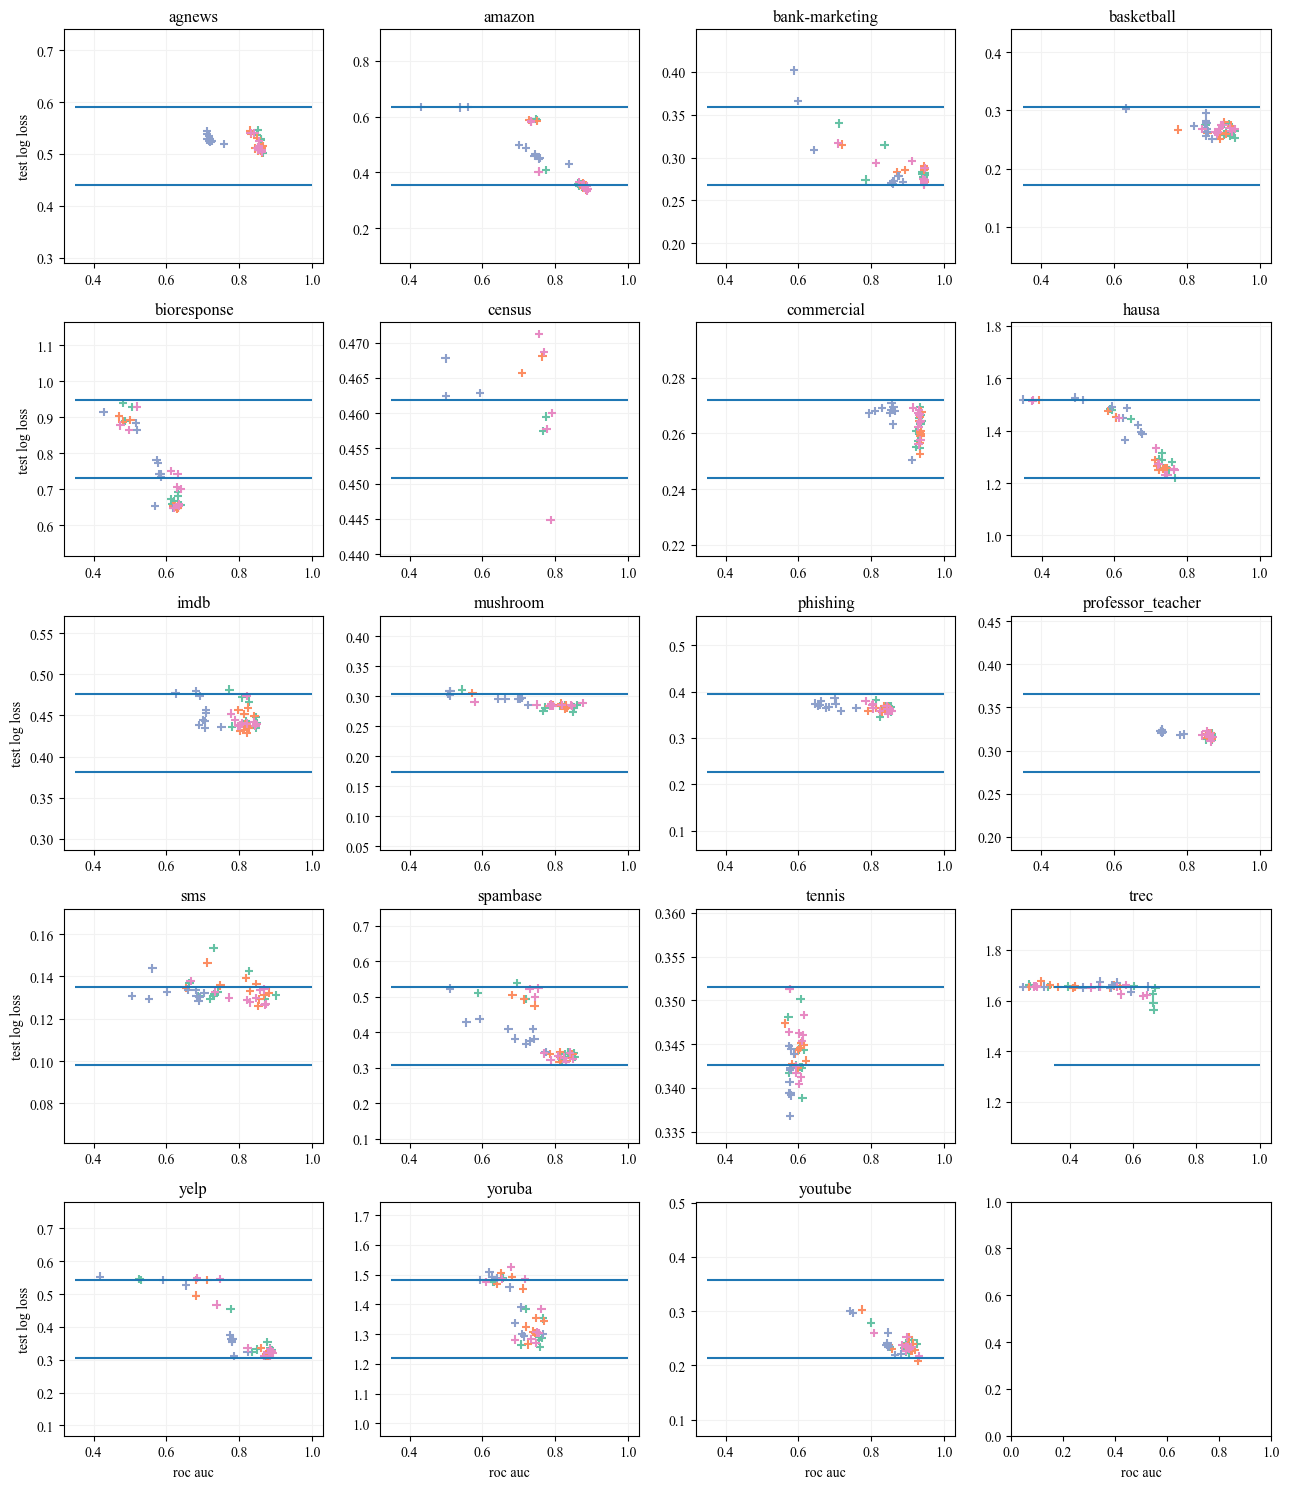

In [15]:
prefix = "weak/klm"
exp_alt = "allclass"


results_cv = all_results_cv[exp_alt][prefix]["logl"]
logl_cv = all_val_cv[exp_alt][prefix]["logl"]
logl_cv_for_norm = all_val_cv["allclass"][prefix]["logl"]

roc_auc = results_cv["oracl"].pivot(
    index="detector_name", columns="dataset_name", values="global_ranking_quality"
)

n_per_row = 4
n_rows = math.ceil(len(datasets) / n_per_row)
fig, axes = plt.subplots(n_rows, n_per_row, figsize=(13, 3 * n_rows))

for i, dataset_name in enumerate(results_cv["oracl"].dataset_name.unique()):
    axis = axes[i // n_per_row, i % n_per_row]

    axis.set_title(dataset_name)

    d_colors = [full_detector_colors[d] for d in roc_auc.index]

    axis.scatter(
        roc_auc[dataset_name],
        logl_cv["oracl"][dataset_name],
        marker="+",
        c=d_colors,
    )

    perf_none = logl_cv_for_norm["oracl"][dataset_name]["none"]
    perf_silver = logl_cv_for_norm["oracl"][dataset_name]["silver"]
    axis.hlines(perf_none, 0.35, 1)
    axis.hlines(perf_silver, 0.35, 1)

    # axis.set_xlim(0.35, 1)
    print(perf_none, perf_silver)
    axis.set_ylim(2 * perf_silver - perf_none, 2 * perf_none - perf_silver)
    custom_grid(axis)

for axis in axes:
    axis[0].set_ylabel("test log loss")
for axis in axes[-1]:
    axis.set_xlabel("roc auc")

plt.tight_layout()
plt.show()

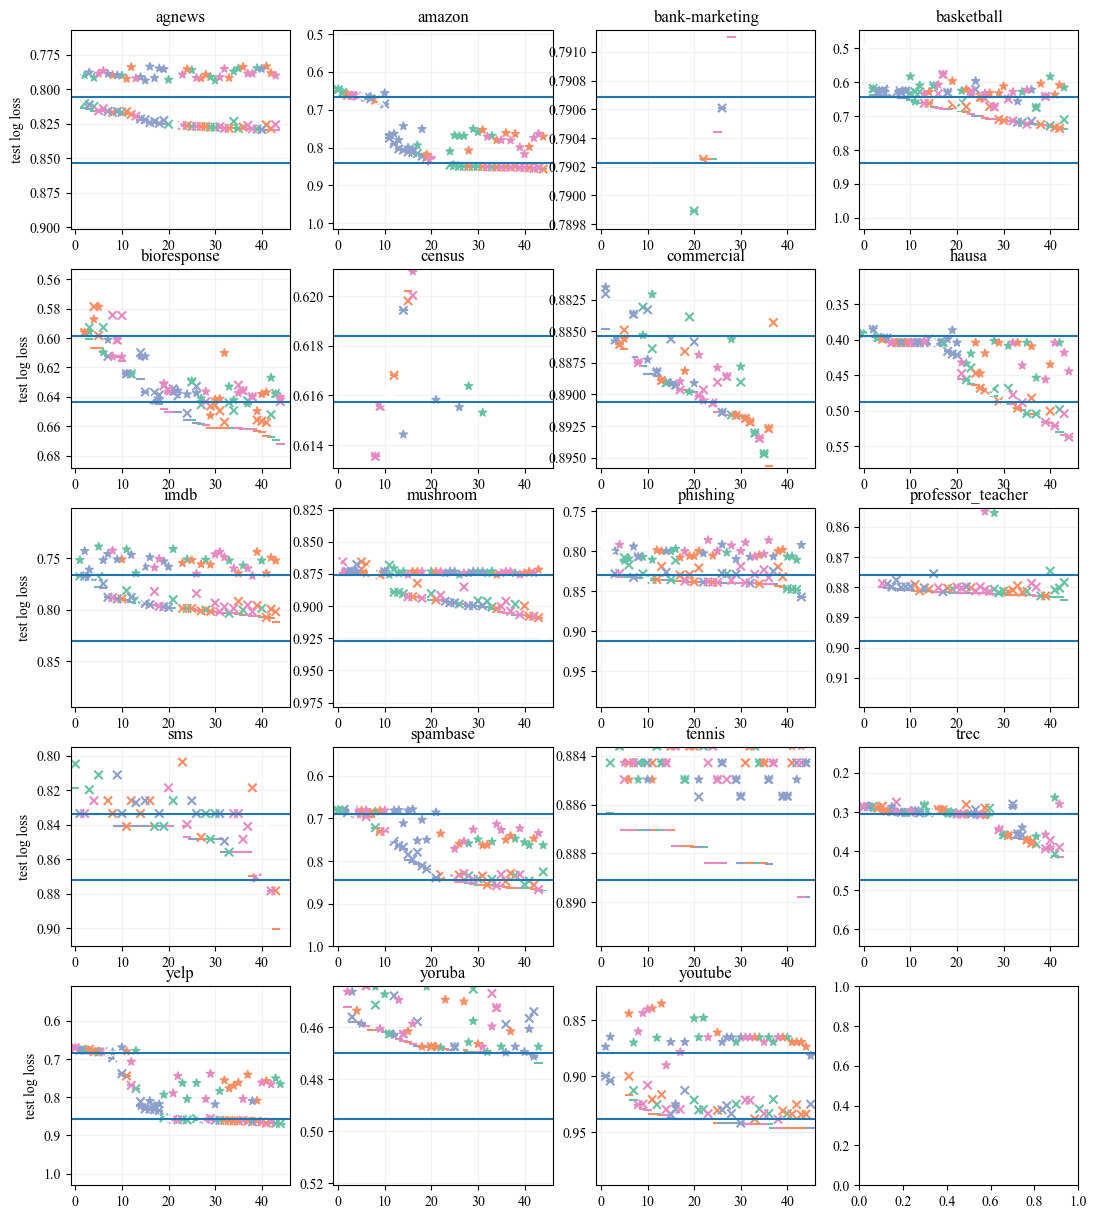

In [16]:
prefix = "weak/klm"
exp_alt = "allclass"

results_cv = all_results_cv[exp_alt][prefix]["bacc"]
logl_cv = all_val_cv[exp_alt][prefix]["bacc"]
logl_cv_for_norm = all_val_cv["allclass"][prefix]["bacc"]

n_per_row = 4
n_rows = math.ceil(len(datasets) / n_per_row)
fig, axes = plt.subplots(n_rows, n_per_row, figsize=(13, 3 * n_rows))

for i, dataset_name in enumerate(results_cv["oracl"].dataset_name.unique()):
    axis = axes[i // n_per_row, i % n_per_row]

    axis.set_title(dataset_name)

    sorted_indices = np.argsort(np.argsort(logl_cv["oracl"][dataset_name].values))
    n_detectors = len(sorted_indices)

    d_colors = [full_detector_colors[d] for d in logl_cv["oracl"][dataset_name].index]

    axis.scatter(
        sorted_indices,
        logl_cv["oracl"][dataset_name],
        marker="_",
        c=d_colors,
    )

    axis.scatter(
        sorted_indices,
        logl_cv["clean"][dataset_name],
        marker="x",
        c=d_colors,
    )

    axis.scatter(
        sorted_indices,
        logl_cv["noisy"][dataset_name],
        marker="*",
        c=d_colors,
    )

    perf_none = logl_cv_for_norm["oracl"][dataset_name]["none"]
    perf_silver = logl_cv_for_norm["oracl"][dataset_name]["silver"]
    axis.hlines(perf_none, -1, n_detectors)
    axis.hlines(perf_silver, -1, n_detectors)

    axis.set_ylim(2 * perf_silver - perf_none, 2 * perf_none - perf_silver)
    axis.set_xlim(-1, n_detectors)
    custom_grid(axis)

for axis in axes:
    axis[0].set_ylabel("test log loss")

if not os.path.exists("figures/summary"):
    os.mkdir("figures/summary/")

plt.savefig(f"figures/summary/{prefix.replace('/', '_')}.pdf", bbox_inches="tight")
plt.show()

In [17]:
results_cv.keys()

dict_keys(['oracl', 'clean', 'noisy', 'noisy_10', 'noisy_90', 'clean_90', 'clean_10'])

In [18]:
hp_tune_str = {
    "clean": "HP tuned on noise free validation",
    "noisy": "HP tuned on noisy validation",
    "oracl": "Oracle HP",
    "noisy_10": "HP tuned on noisy validation, threshold forced at 10\%",
    "noisy_90": "HP tuned on noisy validation, training on 10\% top trusted",
    "clean_90": "HP tuned on clean validation, training on 10\% top trusted",
    "clean_10": "HP tuned on clean validation, training on 90\% top trusted",
}

strategy_str = {
    "allclass": "Filtering",
    "byclass": "Filtering by class",
    "relabel": "10\% relabeling",
}

oracl (1, 19) (1, 19) (46, 19)
['klm_aum', 'klm_cleanlab', 'klm_consensus', 'klm_smallloss']


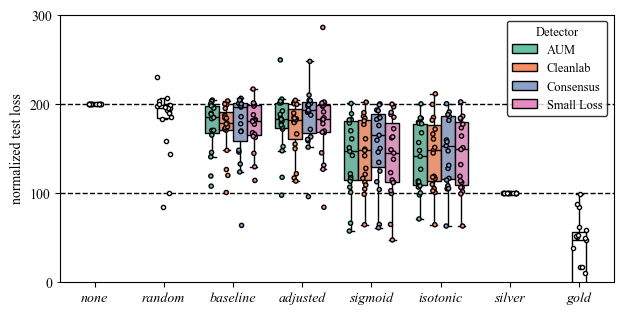

clean (1, 19) (1, 19) (46, 19)
['klm_aum', 'klm_cleanlab', 'klm_consensus', 'klm_smallloss']


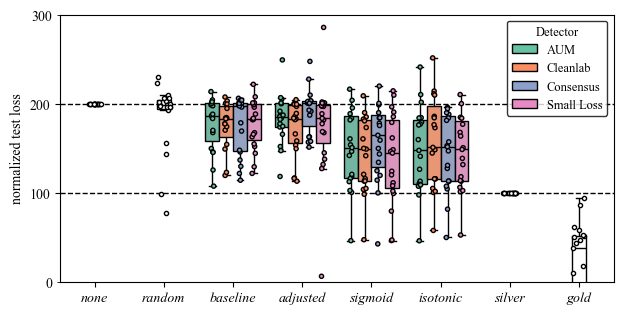

noisy (1, 19) (1, 19) (46, 19)
['klm_aum', 'klm_cleanlab', 'klm_consensus', 'klm_smallloss']


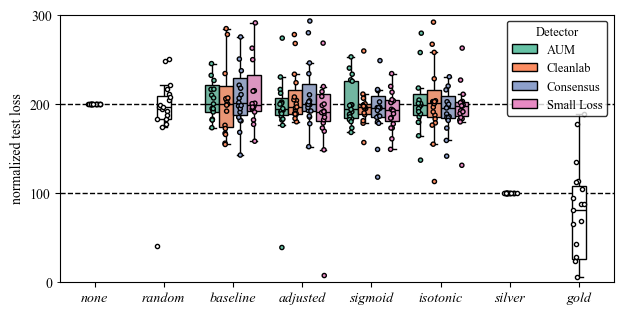

noisy_10 (1, 19) (1, 19) (36, 19)
['klm_aum', 'klm_cleanlab', 'klm_smallloss']


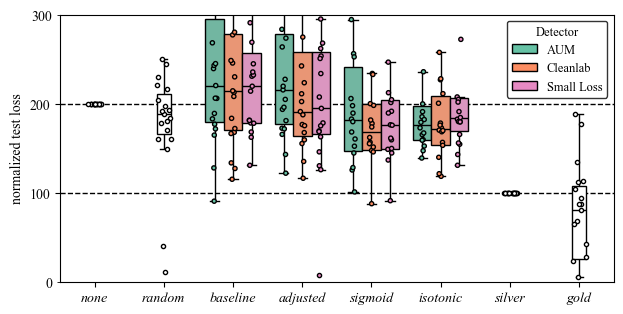

noisy_90 (1, 19) (1, 19) (36, 19)
['klm_aum', 'klm_cleanlab', 'klm_smallloss']


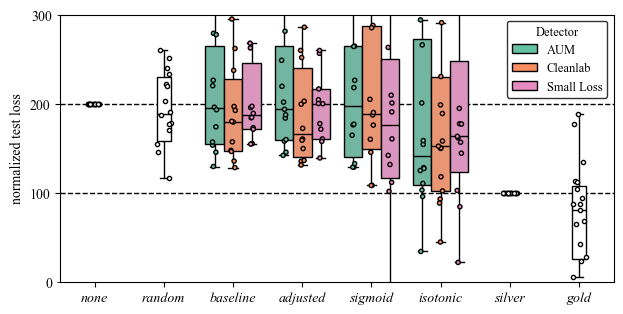

clean_90 (1, 19) (1, 19) (36, 19)
['klm_aum', 'klm_cleanlab', 'klm_smallloss']


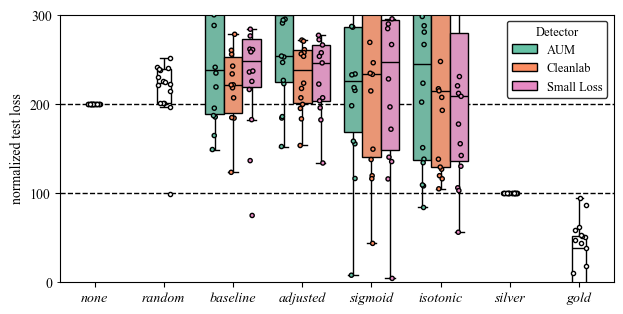

clean_10 (1, 19) (1, 19) (36, 19)
['klm_aum', 'klm_cleanlab', 'klm_smallloss']


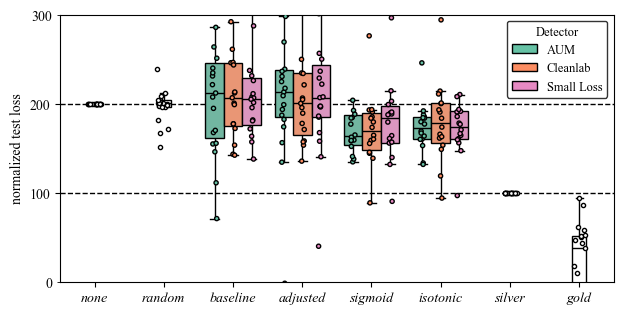

In [ ]:
prefix = "weak/klm"
exp_alt = "allclass"
metric = "logl"
default_calibration_size = str(0.2)

results_cv = all_results_cv[exp_alt][prefix][metric]
logl_cv = all_val_cv[exp_alt][prefix][metric]
logl_cv_for_norm = all_val_cv["allclass"][prefix][metric]

import seaborn as sns
import itertools
from matplotlib.patches import Patch

for k, r in results_cv.items():
    if exp_alt == "relabel" and k in ["noisy_10", "noisy_90", "clean_10", "clean_90"]:
        continue

    logl_cv_none = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    # logl_cv_random = logl_cv[k].loc[logl_cv[k].index == "random"].values
    # logl_cv_wood = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "wood"].values
    logl_cv_silver = (
        logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values
    )
    # logl_cv_gold = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "gold"].values

    # norm_low = (logl_cv_none + logl_cv_wood) / 2
    # norm_high = (logl_cv_silver + logl_cv_gold) / 2

    if False and exp_alt == "relabel":
        norm_low = logl_cv_random
    else:
        norm_low = logl_cv_none
    norm_high = logl_cv_silver

    print(k, norm_low.shape, norm_high.shape, logl_cv[k].shape)
    logl_cv_norm = (logl_cv[k] - norm_low) / (norm_high - norm_low + 1e-10)
    logl_cv_norm = (2 - logl_cv_norm) * 100

    df_sns_format = pd.melt(
        logl_cv_norm.reset_index(),
        id_vars="detector_name",
        value_vars=logl_cv_norm.columns,
    )
    na_mask = df_sns_format["detector_name"].isin(
        [b for b in baselines if b != "isotonic" and b != "sigmoid"] + ["random"]
    )
    calibrated_mask = (
        df_sns_format["detector_name"]
        .str.contains(default_calibration_size)
        .__and__(~df_sns_format["detector_name"].str.contains("noisy"))
    )
    adjusted_mask = df_sns_format["detector_name"].str.contains("adjust")

    selected_mask = calibrated_mask.__or__(
        ~df_sns_format["detector_name"].str.contains("isotonic|sigmoid")
    ).__and__(~na_mask)

    df_sns_format.loc[:, "addon"] = "baseline"
    df_sns_format.loc[calibrated_mask, "addon"] = (
        df_sns_format.loc[calibrated_mask, "detector_name"].str.split("_").str[2]
    )
    df_sns_format.loc[adjusted_mask, "addon"] = (
        df_sns_format.loc[adjusted_mask, "detector_name"].str.split("_").str[2]
    )
    df_sns_format.loc[na_mask, "addon"] = df_sns_format.loc[na_mask, "detector_name"]
    df_sns_format.loc[na_mask, "detector_name"] = "none"
    df_sns_format.loc[~na_mask, "detector_name"] = (
        df_sns_format.loc[~na_mask, "detector_name"]
        .str.split("_")
        .str[:2]
        .str.join("_")
    )

    ordered_detectors = sorted(df_sns_format.loc[selected_mask, "detector_name"].unique())
    print(ordered_detectors)
    ordered_addons = [
        "none",
        "random",
        "baseline",
        "adjusted",
        "sigmoid",
        "isotonic",
        "silver",
        "gold",
    ]

    tf.figure(width=TMLR_textwidth * 0.95, ratio=0.5, pad=0.5)

    sns.boxplot(
        df_sns_format[selected_mask],
        x="addon",
        y="value",
        hue="detector_name",
        hue_order=ordered_detectors,
        palette=sns.color_palette([full_detector_colors[d] for d in ordered_detectors]),
        order=ordered_addons,
        showfliers=False,
        **{
            "boxprops": {"edgecolor": "black"},
            "medianprops": {"color": "black"},
            "whiskerprops": {"color": "black"},
            "capprops": {"color": "black"},
        },
        legend=False,
    )

    sns.boxplot(
        df_sns_format[na_mask],
        x="addon",
        y="value",
        order=ordered_addons,
        showfliers=False,
        width=0.2,
        **{
            "boxprops": {"edgecolor": "black", "facecolor": "white"},
            "medianprops": {"color": "black"},
            "whiskerprops": {"color": "black"},
            "capprops": {"color": "black"},
        },
        legend=False,
    )

    sns.stripplot(
        df_sns_format[selected_mask],
        x="addon",
        y="value",
        hue="detector_name",
        hue_order=ordered_detectors,
        palette=sns.color_palette([full_detector_colors[d] for d in ordered_detectors]),
        order=ordered_addons,
        size=3,
        dodge=True,
        edgecolor="black",
        linewidth=1,
        legend=False,
    )

    sns.stripplot(
        df_sns_format[na_mask],
        x="addon",
        y="value",
        size=3,
        dodge=True,
        edgecolor="black",
        facecolor="white",
        linewidth=1,
        legend=False,
    )

    pretty_xticks = []
    for s in ordered_addons:
        if s in baselines + ["random"]:
            if s == "calibrated":
                pretty_xticks.append("none-cal")
            else:
                pretty_xticks.append(s.replace("_", "\\_"))
        else:
            pretty_xticks.append("\n".join(detect_pretty_name[s].split(" ")))
    plt.xticks(
        range(len(ordered_addons)),
        pretty_xticks,
        style="italic",
    )

    # for i, detector_name in enumerate(ordered_detectors):
    #     if detector_name in baselines:
    #         plt.gca().get_xticklabels()[i].set_color("red")
    #     elif detector_name in ["random"]:
    #         plt.gca().get_xticklabels()[i].set_color("blue")

    plt.yticks([0, 300], [0, 300], minor=True)
    plt.yticks([100, 200], minor=False)

    plt.ylim(0, 300)
    custom_grid(plt.gca())
    plt.grid(axis="x")
    plt.grid(axis="y", which="major", linewidth=1, color="black", linestyle="dashed")
    plt.grid(axis="y", which="minor", linewidth=0, visible=True)

    # # plt.title(f"Hyperparameters tuned using {hp_tune_str[k]} | {prefix} | {exp_alt}")
    plt.ylabel("normalized test loss")
    plt.xlabel("")

    plt.legend(
        handles=[
            Patch(
                facecolor=sns.color_palette(
                    [full_detector_colors[d] for d in ordered_detectors]
                )[i],
                edgecolor="black",
                label=f"{detect_pretty_name[c.split('_')[-1]]}",
            )
            for i, c in enumerate(ordered_detectors)
        ],
        loc="upper right",
        # ncol=2,
        fontsize=9,
        title="Detector",
        # title_fontsize=9,
        title_fontproperties={"size": 9},
        edgecolor="black",
    )

    if not os.path.exists("figures/detectors"):
        # os.mkdir("figures")
        os.mkdir("figures/detectors/")

    tf.savefig(f"figures/detectors/{prefix.replace('/', '_')}_{exp_alt}_{k}_{metric}")

    plt.show()

oracl (1, 19) (1, 19) (46, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_consensus_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_consensus_isotonic', 'klm_smallloss_isotonic']


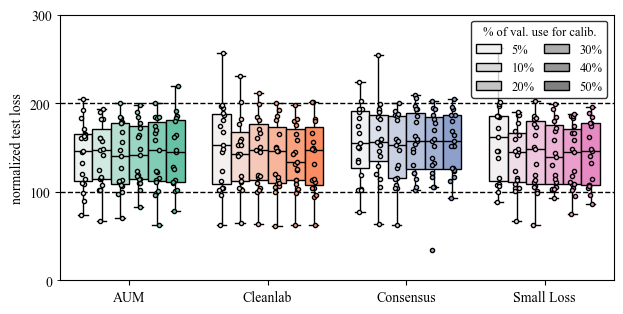

clean (1, 19) (1, 19) (46, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_consensus_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_consensus_isotonic', 'klm_smallloss_isotonic']


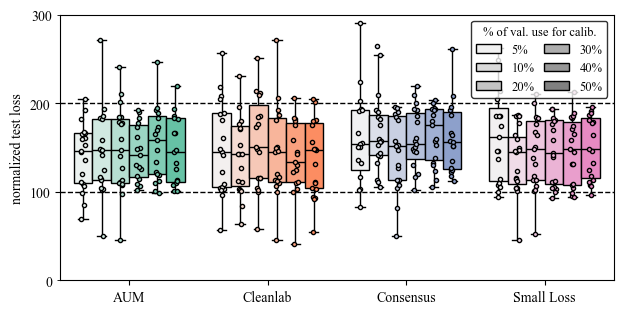

noisy (1, 19) (1, 19) (46, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_consensus_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_consensus_isotonic', 'klm_smallloss_isotonic']


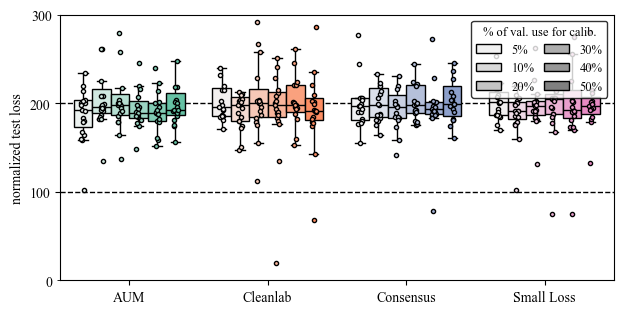

noisy_10 (1, 19) (1, 19) (36, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic']


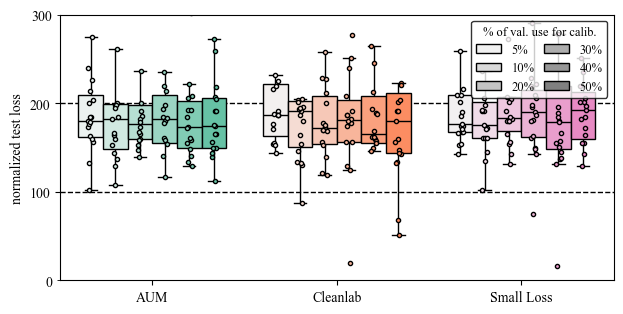

noisy_90 (1, 19) (1, 19) (36, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic']


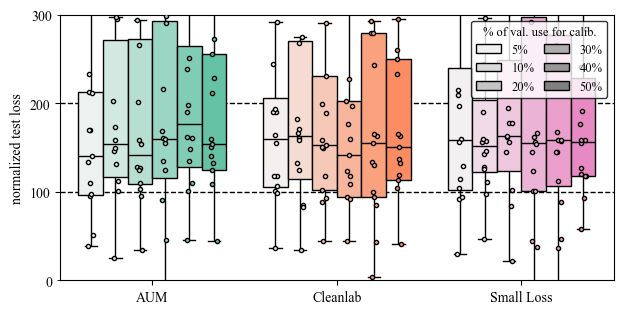

clean_90 (1, 19) (1, 19) (36, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic']


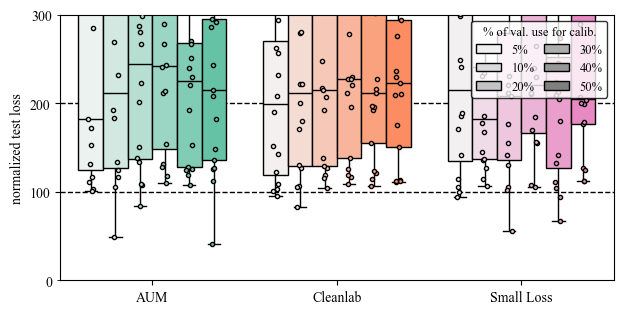

clean_10 (1, 19) (1, 19) (36, 19)
['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic'] [np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)]
[np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5)] ['klm_aum_isotonic', 'klm_cleanlab_isotonic', 'klm_smallloss_isotonic']


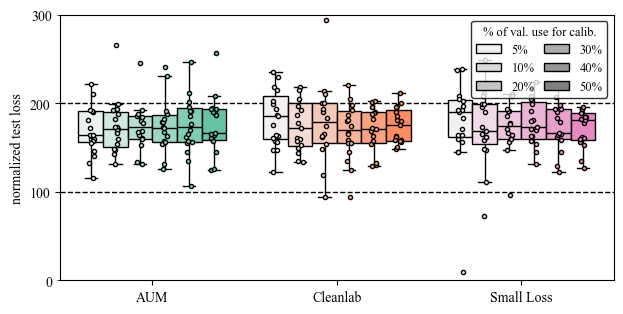

In [ ]:
prefix = "weak/klm"
exp_alt = "allclass"
metric = "logl"
default_calibration_size = str(0.2)

results_cv = all_results_cv[exp_alt][prefix][metric]
logl_cv = all_val_cv[exp_alt][prefix][metric]
logl_cv_for_norm = all_val_cv["allclass"][prefix][metric]

import seaborn as sns
import itertools
from matplotlib.patches import Patch

for k, r in results_cv.items():
    if exp_alt == "relabel" and k in ["noisy_10", "noisy_90", "clean_10", "clean_90"]:
        continue

    logl_cv_none = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    # logl_cv_random = logl_cv[k].loc[logl_cv[k].index == "random"].values
    # logl_cv_wood = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "wood"].values
    logl_cv_silver = (
        logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values
    )
    # logl_cv_gold = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "gold"].values

    # norm_low = (logl_cv_none + logl_cv_wood) / 2
    # norm_high = (logl_cv_silver + logl_cv_gold) / 2

    if False and exp_alt == "relabel":
        norm_low = logl_cv_random
    else:
        norm_low = logl_cv_none
    norm_high = logl_cv_silver

    print(k, norm_low.shape, norm_high.shape, logl_cv[k].shape)
    logl_cv_norm = (logl_cv[k] - norm_low) / (norm_high - norm_low + 1e-10)
    logl_cv_norm = (2 - logl_cv_norm) * 100

    df_sns_format = pd.melt(
        logl_cv_norm.reset_index(),
        id_vars="detector_name",
        value_vars=logl_cv_norm.columns,
    )
    non_baseline_mask = ~df_sns_format["detector_name"].isin(
        ["none", "silver", "gold", "random", "isotonic", "sigmoid"]
    ).__or__(~df_sns_format["detector_name"].str.contains("isotonic")).__or__(
        df_sns_format["detector_name"].str.contains("noisy")
    )
    df_sns_format.loc[non_baseline_mask, "calibration_size"] = (
        df_sns_format.loc[non_baseline_mask, "detector_name"].str.split("_").str[-1]
    ).astype(float)
    df_sns_format.loc[non_baseline_mask, "detector_name"] = (
        df_sns_format.loc[non_baseline_mask, "detector_name"]
        .str.split("_")
        .str[:-1]
        .str.join("_")
    )

    ordered_detectors = sorted(
        df_sns_format.loc[non_baseline_mask, "detector_name"].unique()
    )
    ordered_addons = sorted(
        df_sns_format.loc[non_baseline_mask, "calibration_size"].unique()
    )
    
    tf.figure(width=TMLR_textwidth * 0.95, ratio=0.5, pad=0.5)

    # plt.axhline(100)
    # plt.axhline(200)

    ax = sns.boxplot(
        df_sns_format[non_baseline_mask],
        x="detector_name",
        y="value",
        hue="calibration_size",
        # hue_order=df_sns_format.loc[non_baseline_mask, "calibration_size"].sort_values(),
        showfliers=False,
        **{
            "boxprops": {"edgecolor": "black"},
            "medianprops": {"color": "black"},
            "whiskerprops": {"color": "black"},
            "capprops": {"color": "black"},
        },
        legend=False,
        # palette=sum(
        #     [
        #         sns.light_palette(
        #             full_detector_colors[d + "_0.1"],
        #             n_colors=len(ordered_calibration_sizes),
        #         )
        #         for d in ordered_detectors
        #     ],
        #     [],
        # ),
        # palette = {d: full_detector_colors[d+"_0.1"] for d in df_sns_format.loc[non_baseline_mask, "detector_name"].unique()}
        # boxprops={}
    )

    print(ordered_addons, ordered_detectors)

    for i, box in enumerate(ax.patches):
        if i >= len(ordered_addons) * len(ordered_detectors):
            break
        i, j = i % len(ordered_detectors), i // len(ordered_detectors)
        palette = sns.light_palette(
            full_detector_colors[ordered_detectors[i] + "_" + default_calibration_size],
            n_colors=len(ordered_addons),
        )
        box.set_facecolor(palette[j])

    ax2 = sns.stripplot(
        df_sns_format[non_baseline_mask],
        x="detector_name",
        y="value",
        hue="calibration_size",
        dodge=True,
        size=3,
        # ax=ax,
        edgecolor="black",
        linewidth=1,
        legend=False,
        ax=ax,
    )

    for i, box in enumerate(ax2.collections):
        if i >= len(ordered_addons) * len(ordered_detectors):
            break
        i, j = i % len(ordered_addons), i // len(ordered_addons)
        palette = sns.light_palette(
            full_detector_colors[ordered_detectors[j] + "_" + default_calibration_size],
            n_colors=len(ordered_addons),
        )
        box.set_facecolor(palette[i])

    # for i, detector_name in enumerate(ordered_detectors):
    #     d = logl_cv_norm.loc[logl_cv_norm.index == detector_name].values[0]
    #     # print(len(d))

    #     d_base100 = (2 - d) * 100
    #     d_base100 = d_base100[~np.isnan(d_base100)]
    #     bplot = plt.boxplot(
    #         [d_base100],
    #         positions=[i],
    #         # notch=True,
    #         # bootstrap=100,
    #         widths=[0.7],
    #         showfliers=False,
    #         patch_artist=True,
    #     )

    #     if np.any(np.isnan(d_base100)):
    #         ccc

    #     bplot["boxes"][0].set_facecolor(full_detector_colors[detector_name])
    #     bplot["boxes"][0].set_alpha(0.8)

    #     eps = 0.05
    #     plt.scatter(
    #         [i] * len(d_base100) + np.random.uniform(-eps, eps, size=len(d_base100)),
    #         d_base100,
    #         facecolors=[full_detector_colors[detector_name]] * len(d_base100),
    #         edgecolors="black",
    #         s=[5] * len(d_base100),
    #         zorder=10,
    #     )

    pretty_xticks = []
    for s in ordered_detectors:
        if s in baselines + ["random"]:
            pretty_xticks.append(s.replace("_", "\\_"))
        else:
            pretty_xticks.append(
                " ".join([detect_pretty_name[d] for d in s.split("_")[1:-1]])
            )
    plt.xticks(
        range(len(ordered_detectors)),
        pretty_xticks,
        # rotation=50,
        # rotation_mode="anchor",
        # ha="right",
    )

    # for i, detector_name in enumerate(ordered_detectors):
    #     if detector_name in baselines:
    #         plt.gca().get_xticklabels()[i].set_color("red")
    #     elif detector_name in ["random"]:
    #         plt.gca().get_xticklabels()[i].set_color("blue")

    plt.yticks([0, 300], [0, 300], minor=True)
    plt.yticks([100, 200], minor=False)

    plt.ylim(0, 300)
    custom_grid(plt.gca())
    plt.grid(axis="x")
    plt.grid(axis="y", which="major", linewidth=1, color="black", linestyle="dashed")
    plt.grid(axis="y", which="minor", linewidth=0, visible=True)

    # # plt.title(f"Hyperparameters tuned using {hp_tune_str[k]} | {prefix} | {exp_alt}")
    plt.ylabel("normalized test loss")
    plt.xlabel("")

    plt.legend(
        handles=[
            Patch(
                facecolor=sns.light_palette("grey", n_colors=len(ordered_addons))[i],
                edgecolor="black",
                label=f"{int(100 * float(c))}%",
            )
            for i, c in enumerate(ordered_addons)
        ],
        loc="upper right",
        ncol=2,
        fontsize=9,
        title="% of val. use for calib.",
        title_fontsize=9,
        edgecolor="black",
        columnspacing=0.8,
    )

    # noise_str = "NCAR" if prefix.split("/")[0] == "noise" else "NNAR"
    # classif_str = (
    #     "Linear Classifier"
    #     if prefix.split("/")[1] == "klm"
    #     else "Gradient Boosting Classifier"
    # )
    # # plt.suptitle(f"{hp_tune_str[k]}")
    # # plt.suptitle(
    # #     f"{noise_str} | {strategy_str[exp_alt]} | {classif_str} | {hp_tune_str[k]}"
    # # )

    if not os.path.exists("figures/calib_size"):
        # os.mkdir("figures")
        os.mkdir("figures/calib_size/")

    tf.savefig(f"figures/calib_size/{prefix.replace('/', '_')}_{exp_alt}_{k}_{metric}")

    plt.show()

klm_aum
klm_consensus
klm_cleanlab
klm_smallloss


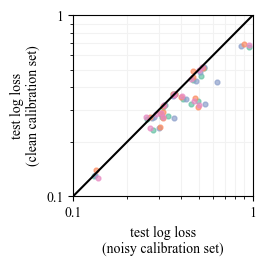

In [37]:
def plot_perf_clean_vs_noisy_calib(suffix, k, exp_alt):
    logl_cv_weak = all_val_cv[exp_alt]["weak" + suffix]["logl"][k]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines) - set(["random"]):

        if (
            "adjusted" in detector
            or "isotonic" in detector
            or "sigmoid" in detector
            or "nois" in detector
            or "gb" in detector
            or "forget" in detector
        ):
            continue
        print(detector)

        perf_noise = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}_isotonic_noisy_0.2"]
        perf_clean = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}_isotonic_0.2"]

        if perf_noise.shape != perf_clean.shape:
            return None

        plt.scatter(
            perf_noise,
            perf_clean,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            # marker=full_detector_markers[detector],
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black")
    plt.xlabel("test log loss\n(noisy calibration set)")
    plt.ylabel("test log loss\n(clean calibration set)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 1)
    plt.ylim(1e-1, 1)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)
    # plt.grid()

    tf.savefig(f"figures/perf_clean_vs_noisy_calib/{exp_alt}{suffix.replace('/','_')}")
    plt.show()


if not os.path.exists("figures/perf_clean_vs_noisy_calib"):
    os.mkdir("figures/perf_clean_vs_noisy_calib")

plot_perf_clean_vs_noisy_calib(suffix="/klm", k="clean", exp_alt="allclass")

klm_aum
klm_consensus
klm_cleanlab
klm_smallloss


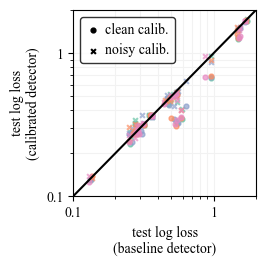

In [38]:
default_calibration_size = 0.2


def plot_perf_clean_vs_noisy_calib(suffix, k, exp_alt):
    logl_cv_weak = all_val_cv[exp_alt]["weak" + suffix]["logl"][k]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines) - set(["random"]):
        if (
            "adjusted" in detector
            or "isotonic" in detector
            or "sigmoid" in detector
            or "nois" in detector
            or "gb" in detector
            or "forget" in detector
        ):
            continue

        print(detector)

        perf_nothing = logl_cv_weak.loc[logl_cv_weak.index == f"{detector}"]
        perf_noise = logl_cv_weak.loc[
            logl_cv_weak.index
            == f"{detector}_isotonic_noisy_{default_calibration_size}"
        ]
        perf_clean = logl_cv_weak.loc[
            logl_cv_weak.index == f"{detector}_isotonic_{default_calibration_size}"
        ]

        if perf_noise.shape != perf_clean.shape:
            return None

        plt.scatter(
            perf_nothing,
            perf_clean,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            # marker=full_detector_markers[detector],
        )
        plt.scatter(
            perf_nothing,
            perf_noise,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            marker="x",
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([0.1, 2], [0.1, 2], color="black")
    plt.xlabel("test log loss\n(baseline detector)")
    plt.ylabel("test log loss\n(calibrated detector)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 2)
    plt.ylim(1e-1, 2)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.append(np.arange(0.1, 1, 0.1), 2), [], minor=True)
    plt.yticks(np.append(np.arange(0.1, 1, 0.1), 2), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)
    # plt.grid()
    plt.scatter([], [], color="black", label="clean calib.", s=12)
    plt.scatter([], [], color="black", label="noisy calib.", marker="x", s=12)
    plt.legend(edgecolor="black", handletextpad=0.4, handlelength=1)

    tf.savefig(f"figures/perf_clean_vs_noisy_calib/{exp_alt}{suffix.replace('/', '_')}")
    plt.show()


if not os.path.exists("figures/perf_clean_vs_noisy_calib"):
    os.mkdir("figures/perf_clean_vs_noisy_calib")

plot_perf_clean_vs_noisy_calib(suffix="/klm", k="clean", exp_alt="allclass")

clean (1, 19) (1, 19) (46, 19)
klm_aum
klm_consensus
klm_cleanlab
klm_smallloss


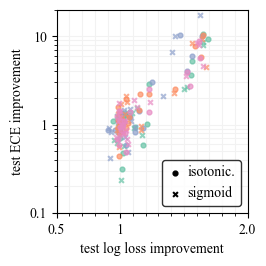

In [39]:
import re


def plot_improv_ece_improv_detect(prefix, k, exp_alt):
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_model = (
        all_results[exp_alt][prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )

    # results_cv = all_results_cv[exp_alt][prefix][metric]
    logl_cv = all_val_cv[exp_alt][prefix][metric]
    logl_cv_for_norm = all_val_cv["allclass"][prefix][metric]

    logl_cv_none = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    # logl_cv_random = logl_cv[k].loc[logl_cv[k].index == "random"].values
    # logl_cv_wood = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "wood"].values
    logl_cv_silver = (
        logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values
    )
    # logl_cv_gold = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "gold"].values

    # norm_low = (logl_cv_none + logl_cv_wood) / 2
    # norm_high = (logl_cv_silver + logl_cv_gold) / 2

    if False and exp_alt == "relabel":
        norm_low = logl_cv_random
    else:
        norm_low = logl_cv_none
    norm_high = logl_cv_silver

    print(k, norm_low.shape, norm_high.shape, logl_cv[k].shape)
    logl_cv_norm = (logl_cv[k] - norm_low) / (norm_high - norm_low + 1e-10)
    logl_cv_norm = (2 - logl_cv_norm) * 100

    ece = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values=f"ece_{mapping[k]}",
        )
    )

    logl = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values=f"logl_{mapping[k]}",
        )
    )

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines + ["random"]):
        if len(detector.split("_")) > 2:
            continue

        print(detector)
        y1 = (
            ece.loc[ece.index == detector].values
            / ece.loc[ece.index == f"{detector}_isotonic_0.2"].values
        )

        x1 = (
            logl.loc[logl.index == detector].values
            / logl.loc[logl.index == f"{detector}_isotonic_0.2"].values
        )

        y2 = (
            ece.loc[ece.index == detector].values
            / ece.loc[ece.index == f"{detector}_sigmoid_0.2"].values
        )

        x2 = (
            logl.loc[logl.index == detector].values
            / logl.loc[logl.index == f"{detector}_sigmoid_0.2"].values
        )

        plt.scatter(x1, y1, color=full_detector_colors[detector], s=12, alpha=0.7)

        plt.scatter(
            x2, y2, color=full_detector_colors[detector], s=12, alpha=0.7, marker="x"
        )

    # plt.plot([0, 0.5], [0, 0.5], color="black")

    plt.ylabel("test ECE improvement")
    plt.xlabel("test log loss improvement")

    plt.scatter([], [], color="black", label="isotonic.", s=12)
    plt.scatter([], [], color="black", label="sigmoid", marker="x", s=12)

    plt.yscale("log")
    # plt.yscale("log")

    custom_grid(plt.gca())
    plt.ylim(0.1, 20)
    plt.xlim(0.5, 2)

    # plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks([0.1, 1, 10], [0.1, 1, 10], minor=False)

    plt.xticks(np.arange(0.5, 2, 0.1), [], minor=True)
    plt.xticks([0.5, 1, 2.0], [0.5, 1, 2.0], minor=False)

    plt.legend(loc="lower right", edgecolor="black", handletextpad=0.4, handlelength=1)

    tf.savefig(f"figures/improv_ece_improv_detect/{exp_alt}_{prefix.replace('/', '_')}")
    plt.show()


if not os.path.exists("figures/improv_ece_improv_detect"):
    os.mkdir("figures/improv_ece_improv_detect")

plot_improv_ece_improv_detect(prefix="weak/klm", k="clean", exp_alt="allclass")

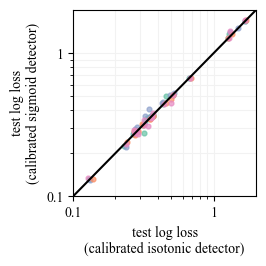

In [ ]:
def plot_corr_sig_iso(prefix, k, exp_alt):
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_model = (
        all_results[exp_alt][prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )

    logl = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="logl_test",
        )
    )

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines + ["random"]):
        if len(detector.split("_")) > 2:
            continue

        x = logl.loc[logl.index == f"{detector}_isotonic_0.2"].values
        y = logl.loc[logl.index == f"{detector}_sigmoid_0.2"].values

        plt.scatter(x, y, color=full_detector_colors[detector], s=12, alpha=0.7)

    plt.xlabel("test log loss\n(calibrated isotonic detector)")
    plt.ylabel("test log loss\n(calibrated sigmoid detector)")

    # plt.scatter([], [], color="black", label="isotonic.", s=12)
    # plt.scatter([], [], color="black", label="sigmoid", marker="x", s=12)

    plt.xscale("log")
    plt.yscale("log")

    plt.plot([0.1, 2], [0.1, 2], color="black")

    custom_grid(plt.gca())
    plt.ylim(0.1, 2)
    plt.xlim(0.1, 2)

    plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)

    plt.yticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)

    # plt.legend(loc="lower right", edgecolor="black", handletextpad=0.4, handlelength=1)

    tf.savefig(f"figures/plot_corr_sig_iso/{exp_alt}_{prefix.replace('/', '_')}")
    plt.show()


if not os.path.exists("figures/plot_corr_sig_iso"):
    os.mkdir("figures/plot_corr_sig_iso")

plot_corr_sig_iso(prefix="weak/klm", k="clean", exp_alt="allclass")

In [ ]:

from sklearn.linear_model import HuberRegressor, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def plot_improv_ece_improv_detect_2(prefix, k, exp_alt):
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_model = (
        all_results[exp_alt][prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )

    # # results_cv = all_results_cv[exp_alt][prefix][metric]
    # logl_cv = all_val_cv[exp_alt][prefix][metric]
    # logl_cv_for_norm = all_val_cv["allclass"][prefix][metric]

    # logl_cv_none = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "none"].values
    # # logl_cv_random = logl_cv[k].loc[logl_cv[k].index == "random"].values
    # # logl_cv_wood = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "wood"].values
    # logl_cv_silver = (
    #     logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "silver"].values
    # )
    # # logl_cv_gold = logl_cv_for_norm[k].loc[logl_cv_for_norm[k].index == "gold"].values

    # # norm_low = (logl_cv_none + logl_cv_wood) / 2
    # # norm_high = (logl_cv_silver + logl_cv_gold) / 2

    # if False and exp_alt == "relabel":
    #     norm_low = logl_cv_random
    # else:
    #     norm_low = logl_cv_none
    # norm_high = logl_cv_silver

    # print(k, norm_low.shape, norm_high.shape, logl_cv[k].shape)
    # logl_cv_norm = (logl_cv[k] - norm_low) / (norm_high - norm_low + 1e-10)
    # logl_cv_norm = (2 - logl_cv_norm) * 100

    ece = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="ece_train",
        )
    )
    print(ece)

    logl = (
        all_results[exp_alt][prefix]
        .iloc[best_model]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values=f"logl_{mapping[k]}",
        )
    )

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    X1 = []
    Y1 = []
    X2 = []
    Y2 = []

    for detector in set(detectors) - set(baselines + ["random"]):
        if len(detector.split("_")) > 2:
            continue

        print(detector)
        x1 = (
            ece.loc[ece.index == "none"].values
            / ece.loc[ece.index == "isotonic"].values
        )

        y1 = (
            logl.loc[logl.index == detector].values
            / logl.loc[logl.index == f"{detector}_isotonic_0.2"].values
        )

        x2 = (
            ece.loc[ece.index == "none"].values / ece.loc[ece.index == "sigmoid"].values
        )

        y2 = (
            logl.loc[logl.index == detector].values
            / logl.loc[logl.index == f"{detector}_sigmoid_0.2"].values
        )

        plt.scatter(x1, y1, color=full_detector_colors[detector], s=12, alpha=0.7)
        plt.scatter(
            x2, y2, color=full_detector_colors[detector], s=12, alpha=0.7, marker="x"
        )
        X1.extend(x1.tolist())
        X2.extend(x2.tolist())
        Y1.extend(y1.tolist())
        Y2.extend(y2.tolist())

    # plt.plot([0, 0.5], [0, 0.5], color="black")

    lr1 = make_pipeline(PolynomialFeatures(), LinearRegression())
    lr2 =make_pipeline(PolynomialFeatures(), LinearRegression())
    lr1.fit(np.asarray(X1).reshape(-1, 1), np.asarray(Y1).ravel())
    lr2.fit(np.asarray(X2).reshape(-1, 1), np.asarray(Y2).ravel())

    print(np.linspace(*plt.xlim(), num=100))
    plt.plot(
        xx := np.linspace(*plt.xlim(), num=100),
        lr1.predict(xx.reshape(-1, 1)),
    )
    plt.plot(
        xx := np.linspace(*plt.xlim(), num=100),
        lr2.predict(xx.reshape(-1, 1)),
    )

    plt.xlabel("train ECE improvement")
    plt.ylabel("test log loss improvement")

    # plt.scatter([], [], color="black", label="isotonic.", s=12)
    # plt.scatter([], [], color="black", label="sigmoid", marker="x", s=12)

    # plt.xscale("log")
    # plt.yscale("log")

    custom_grid(plt.gca())
    # plt.ylim(0.1, 20)
    # plt.xlim(1, 100)

    # plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    # plt.xticks([0.1, 1, 10], [0.1, 1, 10], minor=False)

    # plt.yticks(np.arange(0.5, 2, 0.1), [], minor=True)
    # plt.yticks([0.5, 1, 2.0], [0.5, 1, 2.0], minor=False)

    # plt.legend(loc="lower right", edgecolor="black", handletextpad=0.4, handlelength=1)

    tf.savefig(
        f"figures/improv_ece_improv_detect2/{exp_alt}_{prefix.replace('/', '_')}"
    )
    plt.show()


if not os.path.exists("figures/improv_ece_improv_detect2"):
    os.mkdir("figures/improv_ece_improv_detect2")

plot_improv_ece_improv_detect_2(prefix="weak/klm", k="clean", exp_alt="allclass")

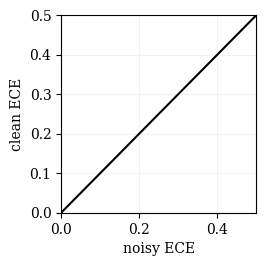

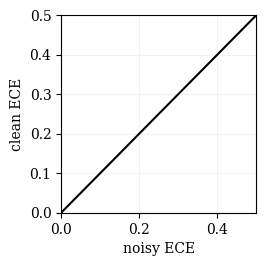

IndexError: index 0 is out of bounds for axis 0 with size 0

<Figure size 260.051x260.051 with 0 Axes>

In [ ]:
def plot_calib_noisy_clean(prefix, k, exp_alt):

    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_model = (
        all_results[exp_alt][prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )

    ece = {}
    for eval_split in ["val", "test", "noisy_val"]:

        ece[eval_split] = (
            all_results[exp_alt][prefix]
            .iloc[best_model]
            .pivot(
                index="detector_name",
                columns="dataset_name",
                values=f"ece_{eval_split}",
            )
        )

    alternatives = ["adjusted", "calibrated"]

    for base in ["gb", "klm"]:

        for alternative in alternatives:
            tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

            for detector in set(detectors) - set(baselines + ["random"]):

                if not detector.startswith(base) or any(
                    detector.endswith(alternative) for alternative in alternatives
                ):
                    continue

                x1 = ece["noisy_val"].loc[ece["noisy_val"].index == detector]
                y1 = ece["val"].loc[ece["val"].index == detector]

                x2 = ece["noisy_val"].loc[
                    ece["noisy_val"].index == f"{detector}_{alternative}"
                ]
                y2 = ece["val"].loc[ece["val"].index == f"{detector}_{alternative}"]

                for i in range(len(x1.values.ravel())):
                    plt.annotate(
                        "",
                        (x2.values.ravel()[i], y2.values.ravel()[i]),
                        (x1.values.ravel()[i], y1.values.ravel()[i]),
                        arrowprops={
                            "arrowstyle": "->",
                            "color": colormaps["tab20"].colors[i],
                            "shrinkA": 0,
                            "shrinkB": 0,
                        },
                    )

            xlims, ylims = plt.xlim(), plt.ylim()
            xy_min = min(xlims[0], ylims[0])
            xy_max = max(xlims[1], ylims[1])

            plt.plot([0, 0.5], [0, 0.5], color="black")

            plt.xlabel("noisy ECE")
            plt.ylabel("clean ECE")

            custom_grid(plt.gca())
            plt.xlim(0, 0.5)
            plt.ylim(0, 0.5)

            tf.savefig(
                f"figures/calib_clean_vs_noisy/{exp_alt}_{prefix.replace('/','_')}_{alternative}_{base}"
            )
            plt.show()


if not os.path.exists("figures/calib_clean_vs_noisy"):
    os.mkdir("figures/calib_clean_vs_noisy")

plot_calib_noisy_clean(prefix="weak/klm", k="oracl", exp_alt="allclass")

FileNotFoundError: [Errno 2] No such file or directory: 'figures/clean_vs_noisy/allclass_weak_klm.pdf'

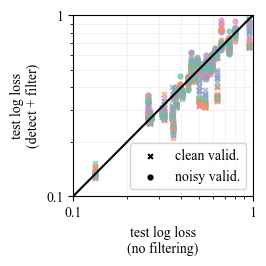

In [ ]:
def plot_clean_noisy(prefix, exp_alt):
    logl_cv_noisy = all_val_cv[exp_alt][prefix]["logl"]["noisy"]
    logl_cv_clean = all_val_cv[exp_alt][prefix]["logl"]["clean"]
    logl_cv_noisy_none = logl_cv_noisy.loc[logl_cv_noisy.index == "none"]
    logl_cv_clean_none = logl_cv_clean.loc[logl_cv_clean.index == "none"]

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector in set(detectors) - set(baselines):

        perf_noisy = logl_cv_noisy.loc[logl_cv_noisy.index == detector]
        perf_clean = logl_cv_clean.loc[logl_cv_clean.index == detector]

        plt.scatter(
            logl_cv_noisy_none,
            perf_noisy,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
        )

        plt.scatter(
            logl_cv_clean_none,
            perf_clean,
            color=full_detector_colors[detector],
            s=12,
            alpha=0.7,
            marker="x",
        )

    xlims, ylims = plt.xlim(), plt.ylim()
    xy_min = min(xlims[0], ylims[0])
    xy_max = max(xlims[1], ylims[1])

    plt.plot([xy_min, xy_max], [xy_min, xy_max], color="black")

    plt.xlabel("test log loss\n(no filtering)")
    plt.ylabel("test log loss\n(detect + filter)")

    custom_grid(plt.gca())
    plt.xlim(1e-1, 1)
    plt.ylim(1e-1, 1)
    plt.xscale("log")
    plt.yscale("log")

    plt.xticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0.1, 1, 0.1), [], minor=True)
    plt.xticks([0.1, 1], [0.1, 1], minor=False)
    plt.yticks([0.1, 1], [0.1, 1], minor=False)

    plt.scatter([], [], color="black", label=f"clean valid.", marker="x", s=12)
    plt.scatter([], [], color="black", label=f"noisy valid.", s=12)
    plt.legend()

    tf.savefig(f"figures/clean_vs_noisy/{exp_alt}_{prefix.replace('/','_')}")
    plt.show()


plot_clean_noisy(prefix="weak/klm", exp_alt="allclass")

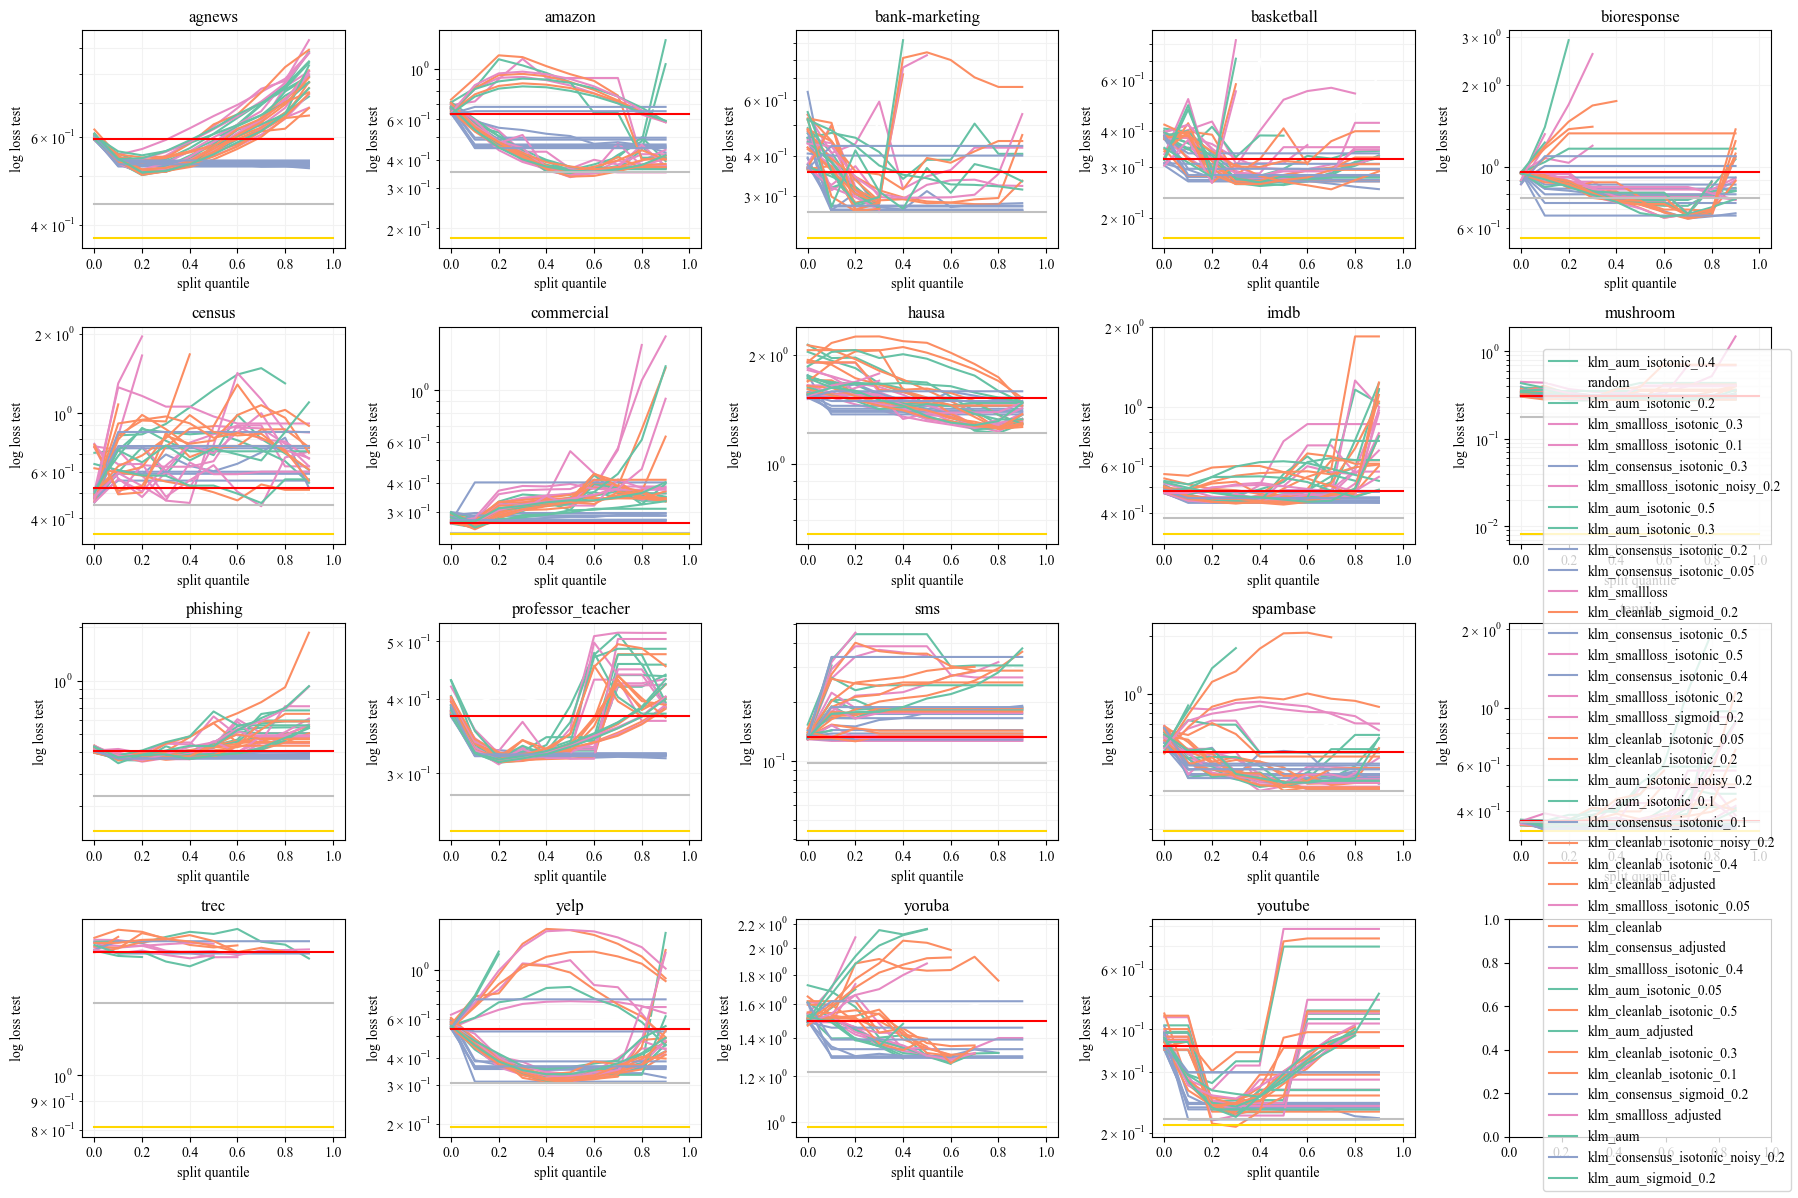

In [ ]:
prefix = "weak/klm"
exp_alt = "allclass"

hp_pivot = all_results_cv[exp_alt][prefix]["logl"]["clean"].pivot(
    values="params_classifier", index="dataset_name", columns="detector_name"
)
res = all_results[exp_alt][prefix]
res_none = all_results_cv[exp_alt][prefix]["logl"]["clean"][
    all_results_cv[exp_alt][prefix]["logl"]["clean"]["detector_name"] == "none"
][["dataset_name", "logl_test"]].set_index("dataset_name")
res_silver = all_results_cv[exp_alt][prefix]["logl"]["clean"][
    all_results_cv[exp_alt][prefix]["logl"]["clean"]["detector_name"] == "silver"
][["dataset_name", "logl_test"]].set_index("dataset_name")
res_gold = all_results_cv[exp_alt][prefix]["logl"]["clean"][
    all_results_cv[exp_alt][prefix]["logl"]["clean"]["detector_name"] == "gold"
][["dataset_name", "logl_test"]].set_index("dataset_name")

mult = 1.5
fig, axes = plt.subplots(4, 5, figsize=(12 * mult, 8 * mult))

for i, dataset in enumerate(datasets):
    axis = axes[i // 5][i % 5]

    for detector in set(detectors) - {"gb_consensus", "klm_consensus"} - set(baselines):
        hp_this = hp_pivot.loc[dataset][detector]
        logl_this = res[(res.dataset_name == dataset) & (res.detector_name == detector)]
        logl_this = logl_this[logl_this.params_classifier.apply(lambda x: x == hp_this)]

        split_quantiles = []
        logls = []
        for p_split, logl in logl_this[["params_splitter", "logl_test"]].itertuples(
            index=False
        ):
            split_quantiles.append(p_split["quantile"] if "quantile" in p_split else p_split["threshold"])
            logls.append(logl)

        axis.plot(split_quantiles, logls, label=detector, color=full_detector_colors[detector])

    axis.plot([0, 1], [res_none.loc[dataset].values] * 2, color="red")
    axis.plot([0, 1], [res_silver.loc[dataset].values] * 2, color="silver")
    axis.plot([0, 1], [res_gold.loc[dataset].values] * 2, color="gold")

    custom_grid(axis)
    axis.set_title(dataset)
    # axis.legend()
    axis.set_xlabel("split quantile")
    axis.set_ylabel("log loss test")
    axis.set_xlim()
    axis.set_yscale("log")

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right')

fig.tight_layout()
plt.show()

In [29]:
detect_dirs = [
    (
        "weak",
        os.path.join(os.path.expanduser("~"), f"{output_dir}/../ecai-sigmoid/weak"),
    ),
    # (
    #     "noise",
    #     os.path.join(os.path.expanduser("~"), f"{output_dir}/detect/noise"),
    # ),
]

exp_alt = "allclass"

all_detect = dict()
for prefix, dir in detect_dirs:
    results_ = []
    methods = os.listdir(dir)

    for method in methods:
        if not os.path.isdir(os.path.join(result_dir, method)):
            continue
        for fname in os.listdir(os.path.join(dir, method)):
            dataset, ext = fname.split(".")
            if ext != "json":
                continue

            with open(os.path.join(dir, method, f"{dataset}.json")) as f:
                results_.append(pd.read_json(f, orient="records"))

    results_ = pd.concat(results_)

    all_detect[prefix] = results_.reset_index(drop=True)
    all_detect[prefix]["detect_run"] = all_detect[prefix].groupby(["dataset_name", "detector_name"]).cumcount()+1

# for k, v in all_results[exp_alt].items():
#     v.loc[pd.isna(v["params_detector"]), "params_detector"] = v.loc[
#         pd.isna(v["params_detector"]), "params"
#     ]
#     v.drop("params", inplace=True, axis=1)

all_merged = dict()
# for prefix in ["weak", "noise"]:
for prefix in ["weak"]:
    all_results[exp_alt][prefix + "/klm"]["params_detector"] = all_results[exp_alt][prefix + "/klm"][
        "params_detector"
    ].astype(str)
    all_detect[prefix]["params"] = all_detect[prefix]["params"].astype(str)

    all_merged[prefix] = pd.merge(
        all_results[exp_alt][prefix + "/klm"],
        all_detect[prefix],
        left_on=["dataset_name", "detector_name", "params_detector"],
        right_on=["dataset_name", "detector_name", "params"],
    )

    all_merged[prefix]["params_detector"] = all_merged[prefix]["params_detector"].apply(
        eval
    )

In [30]:
detect_path = os.path.join(os.path.expanduser("~"), f"{output_dir}/../ecai-sigmoid")
import json
import h5py
import numpy as np
import pandas as pd
from scipy.stats import entropy


class TrustScoreReader:

    def __init__(self, base_path, dataset, detector):

        with open(os.path.join(base_path, detector, f"{dataset}.json"), mode="r") as f:
            self.results_json = json.load(f)
        self.results_hdf5 = h5py.File(
            os.path.join(base_path, detector, f"{dataset}.hdf5"), "r"
        )

        assert len(self.results_hdf5["trust_scores"]) == len(self.results_json)

    def get(self, i):
        return self.results_json[i], self.results_hdf5[f"trust_scores/{i}"][...]

    def length(self):
        return len(self.results_json)

In [31]:
from datasets import get_weak_datasets, datasets_ranked_by_time
import os

datasets_folder = os.path.join(os.path.expanduser("~"), "datasets")

datasets = list(
    filter(
        lambda dataset: dataset not in ["imdb136", "cifar10"], datasets_ranked_by_time
    )
)

weak_datasets = get_weak_datasets(
    cache_folder=datasets_folder,
    corruption="weak",
    seed=1,
    datasets=datasets,
)

# noise_datasets = get_weak_datasets(
#     cache_folder=datasets_folder,
#     corruption="noise",
#     seed=1,
#     datasets=datasets_ranked_by_time,
# )

loaded_datasets = dict(weak=dict(weak_datasets))

In [32]:
loaded_datasets["weak"] = dict(loaded_datasets["weak"] )

/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_36002/2081679782.py:88: RuntimeWarning: invalid value encountered in divide
  prior_untrusted = np.bincount(


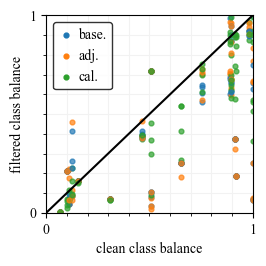

/var/folders/65/rv76bdzx3sv0m6rwzx__cds40000gn/T/ipykernel_36002/2081679782.py:88: RuntimeWarning: invalid value encountered in divide
  prior_untrusted = np.bincount(


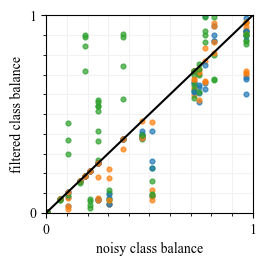

In [51]:
from itertools import product


def plot_class_balance(prefix, reference="clean", k="oracl", exp_alt="allclass"):
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_cv = (
        all_merged[prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )
    best_trust_scores_index = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="detect_run",
        )
    )
    best_split = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="params_splitter",
        )
        .map(
            lambda d: d["quantile"] if "quantile" in d.keys() else d["threshold"],
            na_action="ignore",
        )
    )

    # best_threshold = (
    #     all_merged[prefix]
    #     .iloc[best_cv]
    #     .pivot(
    #         index="detector_name",
    #         columns="dataset_name",
    #         values="params_splitter",
    #     )
    #     .map(lambda dict: dict.get("threshold"))
    # )
    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    top = {detector_name: 0 for detector_name in best_trust_scores_index.index}
    bottom = {detector_name: 0 for detector_name in best_trust_scores_index.index}

    for detector_name, dataset_name in product(
        best_trust_scores_index.index, best_trust_scores_index.columns
    ):
        if (
            "gb" in detector_name
            or "nois" in detector_name
            or "forg" in detector_name
            or "sig" in detector_name
        ):
            continue

        if "iso" in detector_name and "0.2" not in detector_name:
            continue

        trust_score_reader = TrustScoreReader(
            os.path.join(detect_path, prefix), dataset_name, detector_name
        )
        idx = (best_trust_scores_index.loc[detector_name, dataset_name] - 1).item()
        if math.isnan(idx):
            print(detector_name, dataset_name)
            continue
        trust_scores = trust_score_reader.get(int(idx))[1]
        dataset = loaded_datasets[prefix][dataset_name]
        y_train_clean = dataset["train"]["target"]
        y_train_noisy = dataset["train"]["noisy_target"]
        y_test = dataset["test"]["target"]
        unlabeled = y_train_noisy == -1
        y_train_clean = np.asarray(y_train_clean)[~unlabeled]
        y_train_noisy = np.asarray(y_train_noisy)[~unlabeled]
        n_classes = len(np.unique(y_test))
        if "consensus" in detector_name:
            trusted = trust_scores >= best_split.loc[detector_name, dataset_name]
        else:
            trusted = trust_scores >= np.quantile(
                trust_scores, q=best_split.loc[detector_name, dataset_name]
            )
        prior_trusted = np.bincount(y_train_noisy[trusted], minlength=n_classes) / len(
            y_train_noisy[trusted]
        )
        prior_untrusted = np.bincount(
            y_train_noisy[~trusted], minlength=n_classes
        ) / len(y_train_noisy[~trusted])
        prior_clean = np.bincount(y_test, minlength=n_classes) / len(y_test)
        prior_noisy = np.bincount(y_train_noisy, minlength=n_classes) / len(
            y_train_noisy
        )
        x_clean = np.min(prior_clean) / np.max(prior_clean)
        x_noisy = np.min(prior_noisy) / np.max(prior_noisy)
        x = x_clean if reference == "clean" else x_noisy
        y = np.min(prior_trusted) / np.max(prior_trusted)
        plt.scatter(
            x,
            y,
            # color="tab:blue" if x_noisy > x_clean else "tab:orange",
            # color=full_detector_colors[detector_name],
            color="tab:orange"
            if "adjust" in detector_name
            else ("tab:green" if "isotonic" in detector_name else "tab:blue"),
            # marker=full_detector_markers[detector_name],
            # marker=(
            #     "x"
            #     if "adjust" in detector_name
            #     else ("o" if "calib" in detector_name else "s")
            # ),
            alpha=0.7,
            s=12,
        )
        top[detector_name] += np.sum(y > x)
        bottom[detector_name] += np.sum(y <= x)

    plt.ylabel("filtered class balance")
    if reference == "clean":
        plt.xlabel("clean class balance")
    else:
        plt.xlabel("noisy class balance")

    # plt.title(f"{top}/{bottom}")

    custom_grid(plt.gca())

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), color="black")

    plt.xticks(np.arange(0, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0, 1, 0.1), [], minor=True)
    plt.xticks([0, 1], [0, 1], minor=False)
    plt.yticks([0, 1], [0, 1], minor=False)

    if reference == "clean":
        plt.scatter([], [], color="tab:blue", label="base.", s=12)
        plt.scatter([], [], color="tab:orange", label="adj.", s=12)
        plt.scatter([], [], color="tab:green", label="cal.", s=12)
        plt.legend(edgecolor="black", handletextpad=0.4, handlelength=1)

    tf.savefig(f"figures/class_balance/{prefix.replace('/', '_')}_{reference}")
    plt.show()


if not os.path.exists("figures/class_balance"):
    os.mkdir("figures/class_balance")
# plot_class_balance("noise", reference="clean")
# plot_class_balance("noise", reference="noisy")
plot_class_balance("weak", reference="clean", k="clean")
plot_class_balance("weak", reference="noisy", k="clean")

In [ ]:
from datasets import get_weak_datasets, datasets_ranked_by_time
import os

datasets_folder = os.path.join(os.path.expanduser("~"), "datasets")

datasets = list(
    filter(
        lambda dataset: dataset not in ["imdb136", "cifar10"], datasets_ranked_by_time
    )
)

weak_datasets = get_weak_datasets(
    cache_folder=datasets_folder,
    corruption="weak",
    seed=1,
    datasets=datasets,
    calibration=True,
    calibration_size=0.2,
)

# noise_datasets = get_weak_datasets(
#     cache_folder=datasets_folder,
#     corruption="noise",
#     seed=1,
#     datasets=datasets_ranked_by_time,
# )

loaded_datasets = dict(weak=dict(weak_datasets))

In [ ]:
from itertools import product
import scipy.sparse as sp
from sklearn import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import PredefinedSplit
from define_models import klm, kernels


def plot_improv_train_ece_vs_improv_test_loss(prefix, k="oracl", exp_alt="allclass"):
    mapping = {"oracl": "test", "clean": "val", "noisy": "noisy_val"}
    best_cv = (
        all_merged[prefix]
        .groupby(["dataset_name", "detector_name"])[f"logl_{mapping[k]}"]
        .idxmin()
    )
    best_params = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values="params_detector",
        )
    )
    best_loss = (
        all_merged[prefix]
        .iloc[best_cv]
        .pivot(
            index="detector_name",
            columns="dataset_name",
            values=f"logl_{mapping[k]}",
        )
    )

    tf.figure(width=TMLR_textwidth * (2 / 5), ratio=1, pad=0.5)

    for detector_name, dataset_name in product(best_params.index, best_params.columns):
        if (
            "gb" in detector_name
            or "nois" in detector_name
            or "forg" in detector_name
            or "sig" in detector_name
            or "iso" in detector_name
        ):
            continue

        dataset = loaded_datasets[prefix][dataset_name]

        (
            X_train,
            X_val,
            X_test,
            y_train,
            y_val,
            y_test,
            y_noisy_train,
            y_noisy_val,
            y_noisy_test,
            y_soft_train,
            y_soft_val,
            y_soft_test,
        ) = (
            dataset["train"]["data"],
            dataset["validation"]["data"],
            dataset["test"]["data"],
            dataset["train"]["target"],
            dataset["validation"]["target"],
            dataset["test"]["target"],
            dataset["train"]["noisy_target"],
            dataset["validation"]["noisy_target"],
            dataset["test"]["noisy_target"],
            dataset["train"]["soft_targets"],
            dataset["validation"]["soft_targets"],
            dataset["test"]["soft_targets"],
        )
        (
            X_calib,
            y_calib,
            y_noisy_calib,
            y_soft_calib,
        ) = (
            dataset["calibration"]["data"],
            dataset["calibration"]["target"],
            dataset["calibration"]["noisy_target"],
            dataset["calibration"]["soft_targets"],
        )

        X_train = X_train.astype(np.float32)
        X_val = X_val.astype(np.float32)
        X_test = X_test.astype(np.float32)

        unlabeled = y_noisy_train == -1

        if sp.issparse(X_train):
            X_train_labeled = sp.csc_matrix(X_train[~unlabeled])
            X_val = sp.csc_matrix(X_val)
            X_test = sp.csc_matrix(X_test)

        else:
            X_train_labeled = np.asfortranarray(X_train[~unlabeled])
            X_val = np.asfortranarray(X_val)
            X_test = np.asfortranarray(X_test)

        y_train = np.array(y_train)
        y_train_labeled = y_noisy_train[~unlabeled]

        y_calib = np.array(y_calib)
        unlabeled_calib = y_calib == -1
        y_calib_labeled = y_calib[~unlabeled_calib]

        y_train_labeled = np.concatenate((y_noisy_train[~unlabeled], y_calib_labeled))
        calibration_split = np.concatenate(
            (
                -np.ones(X_train[~unlabeled].shape[0]),
                np.zeros(X_calib[~unlabeled_calib].shape[0]),
            )
        )
        if sp.issparse(X_calib):
            X_train_labeled = sp.csc_matrix(
                sp.vstack((X_train[~unlabeled], X_calib[~unlabeled_calib]))
            )
        else:
            X_train_labeled = np.asfortranarray(
                np.vstack((X_train[~unlabeled], X_calib[~unlabeled_calib]))
            )

        classifier = clone(klm)
        classifier.set_params(best_params.loc["none", dataset_name])
        # TODO: CLEAN (sadge)
        if "kernel" in classifier.get_params():
            kernel, param_grid_kernel = kernels[dataset["kernel"]]
            classifier.set_params(kernel=kernel)
        classifier_calibrated = CalibratedClassifierCV(
            classifier,
            cv=PredefinedSplit(calibration_split),
            ensemble=False,
            method="isotonic",
        )

    plt.ylabel("filtered class balance")
    if reference == "clean":
        plt.xlabel("clean class balance")
    else:
        plt.xlabel("noisy class balance")

    # plt.title(f"{top}/{bottom}")

    custom_grid(plt.gca())

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), color="black")

    plt.xticks(np.arange(0, 1, 0.1), [], minor=True)
    plt.yticks(np.arange(0, 1, 0.1), [], minor=True)
    plt.xticks([0, 1], [0, 1], minor=False)
    plt.yticks([0, 1], [0, 1], minor=False)

    if reference == "clean":
        plt.scatter([], [], color="tab:blue", label="base.", s=12)
        plt.scatter([], [], color="tab:orange", label="adj.", s=12)
        plt.scatter([], [], color="tab:green", label="cal.", s=12)
        plt.legend(edgecolor="black", handletextpad=0.4, handlelength=1)

    tf.savefig(f"figures/class_balance/{prefix.replace('/', '_')}_{reference}")
    plt.show()


if not os.path.exists("figures/class_balance"):
    os.mkdir("figures/class_balance")

plot_improv_train_ece_vs_improv_test_loss("weak", k="clean")

Index(['dataset_name', 'noise_ratio_x', 'coverage_x',
       'noisy_class_distribution_x', 'class_distribution_x',
       'ranking_quality_noisy_x', 'ranking_quality_gt_x',
       'global_ranking_quality_x', 'detector_name', 'fitting_time_x',
       'commit_x', 'hostname_x', 'params_detector', 'strategy',
       'ece_noisy_val', 'ece_val', 'ece_test', 'acc_test', 'bacc_test',
       'kappa_test', 'logl_test', 'acc_val', 'bacc_val', 'kappa_val',
       'logl_val', 'acc_noisy_val', 'bacc_noisy_val', 'kappa_noisy_val',
       'logl_noisy_val', 'params_classifier', 'classifier_name',
       'params_splitter', 'estim_time', 'hostname_estim', 'commit_estim',
       'ece_train', 'acc_train', 'bacc_train', 'kappa_train', 'logl_train',
       'noise_ratio_y', 'coverage_y', 'noisy_class_distribution_y',
       'class_distribution_y', 'ranking_quality_noisy_y',
       'ranking_quality_gt_y', 'global_ranking_quality_y', 'fitting_time_y',
       'params', 'commit_y', 'hostname_y', 'detect_run'],
  

NameError: name 'best_trust_scores_index' is not defined

<Figure size 260.051x260.051 with 0 Axes>